<a href="https://colab.research.google.com/github/sinhatanushree21/Deep-learning-powered-ANN-model-to-predict-customer-churn-and-boost-retention-strategies/blob/main/Customer_Rentension_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

In [ ]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop('customerID', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<Axes: >

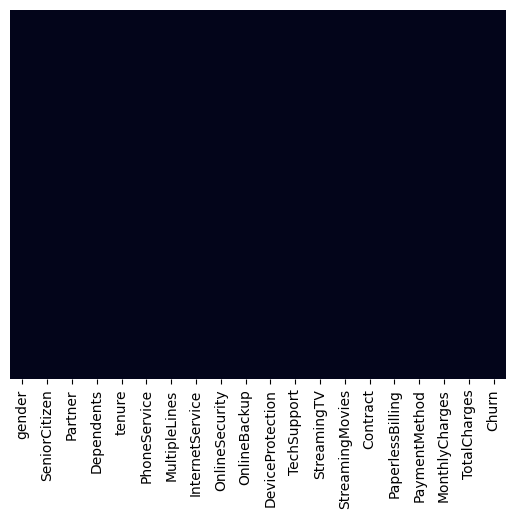

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
pd.to_numeric(df.TotalCharges, errors='coerce').isnull()

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [ ]:
df.loc[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
ndf = df[df.TotalCharges != ' ']
ndf.TotalCharges = pd.to_numeric(ndf.TotalCharges)
ndf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

/tmp/ipython-input-759751419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf.TotalCharges = pd.to_numeric(ndf.TotalCharges)


**Data Visualization**

In [ ]:
ndf.Churn.value_counts()

,count
Churn,
No,5163
Yes,1869


**Churn Count with Tenure**

Text(0.5, 1.0, 'Churn with Tenure Visualization')

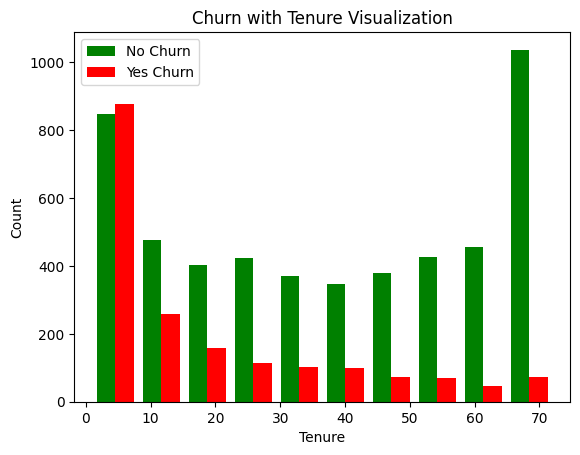

In [ ]:
no_churn_tenure = ndf[ndf.Churn=='No'].tenure
yes_churn_tenure = ndf[ndf.Churn=='Yes'].tenure


plt.hist([no_churn_tenure, yes_churn_tenure], color=['green', 'red'], label=['No Churn', 'Yes Churn'])
plt.legend()
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Churn with Tenure Visualization')

**Monthly Charges vs Customer Churn**

Text(0.5, 1.0, 'Churn Prediction Visualization with Monthly Charges')

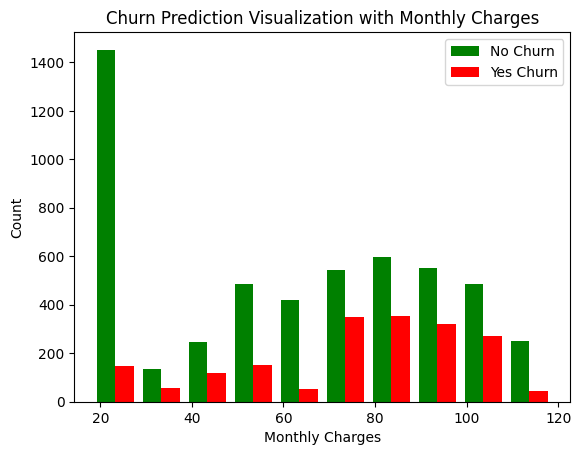

In [ ]:
no_churn_monthlycharges = ndf[ndf.Churn == 'No'].MonthlyCharges
yes_churn_monthlycharges = ndf[ndf.Churn == 'Yes'].MonthlyCharges

plt.hist([no_churn_monthlycharges, yes_churn_monthlycharges], color=['green', 'red'], label=['No Churn', 'Yes Churn'])
plt.legend()
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.title('Churn Prediction Visualization with Monthly Charges')

<Axes: xlabel='gender', ylabel='count'>

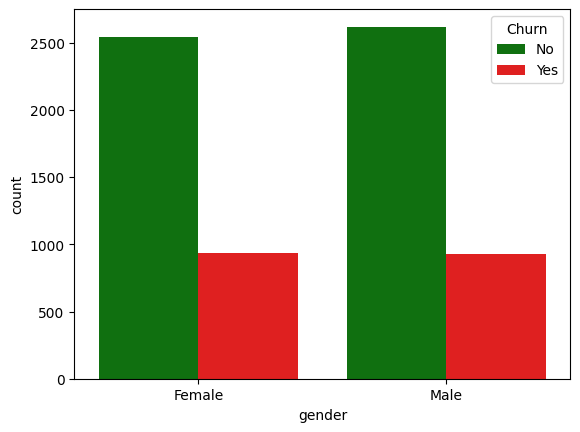

In [ ]:
sns.countplot(x='gender', hue='Churn', data=ndf, palette={'Yes': 'red', 'No': 'green'})

**what is the propotion of senior citizens who are opting for churn**

   gender Churn  count  proportion
0  Female    No    328    0.577465
1  Female   Yes    240    0.422535
2    Male    No    338    0.588850
3    Male   Yes    236    0.411150


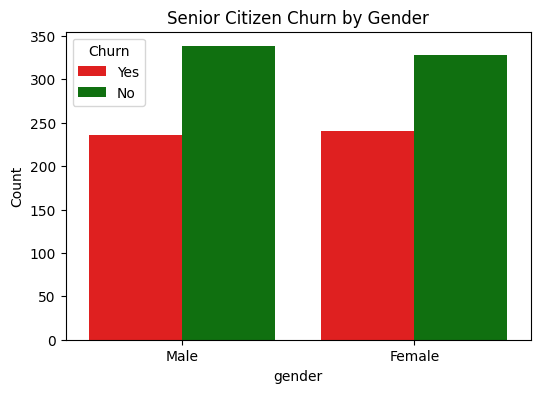

In [ ]:
# Filter senior citizens
senior_df = df[df['SeniorCitizen'] == 1]

# Count by gender and churn
counts = senior_df.groupby(['gender','Churn']).size().reset_index(name='count')

# Compute proportions within each gender
# Calculate the sum of 'count' for each gender group using transform
total_counts_per_gender = counts.groupby('gender')['count'].transform('sum')

# Divide the 'count' by the total 'count' per gender to get the proportion
counts['proportion'] = counts['count'] / total_counts_per_gender

print(counts)


plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=senior_df,
              palette={"Yes":"red","No":"green"})
plt.title("Senior Citizen Churn by Gender")
plt.ylabel("Count")
plt.show()

**What is churn count in case of having partner**

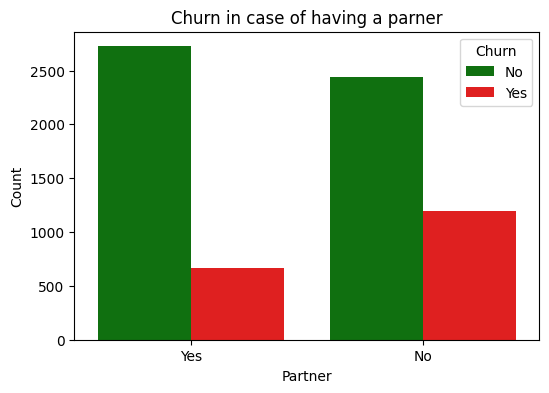

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Partner", hue="Churn", data=ndf,
              palette={"Yes":"red","No":"green"})
plt.title("Churn in case of having a parner")
plt.ylabel("Count")
plt.show()

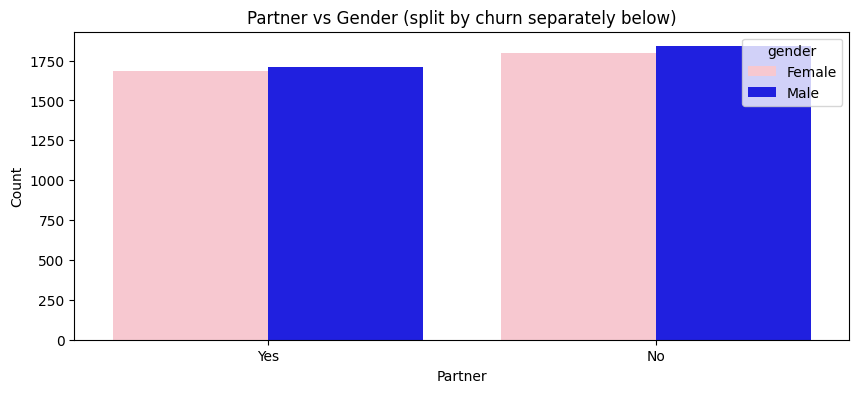

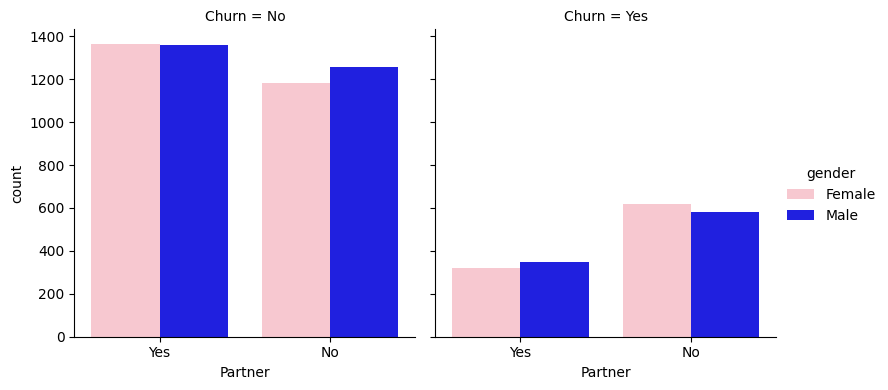

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x="Partner", hue="gender", data=ndf,
              palette={"Female":"pink","Male":"blue"})
plt.title("Partner vs Gender (split by churn separately below)")
plt.ylabel("Count")
plt.show()

# Facet by churn
sns.catplot(x="Partner", hue="gender", col="Churn", data=ndf,
            kind="count", palette={"Female":"pink","Male":"blue"},
            height=4, aspect=1)

/tmp/ipython-input-2153998088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['gender_churn'] = ndf['gender'] + "-" + ndf['Churn']


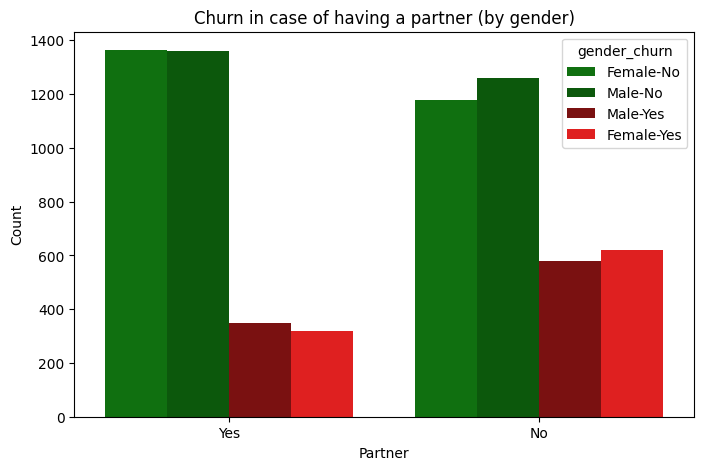

In [ ]:
# Create combined category
ndf['gender_churn'] = ndf['gender'] + "-" + ndf['Churn']

plt.figure(figsize=(8,5))
sns.countplot(x="Partner", hue="gender_churn", data=ndf,
              palette={"Female-Yes":"red","Female-No":"green",
                       "Male-Yes":"darkred","Male-No":"darkgreen"})
plt.title("Churn in case of having a partner (by gender)")
plt.ylabel("Count")
plt.show()


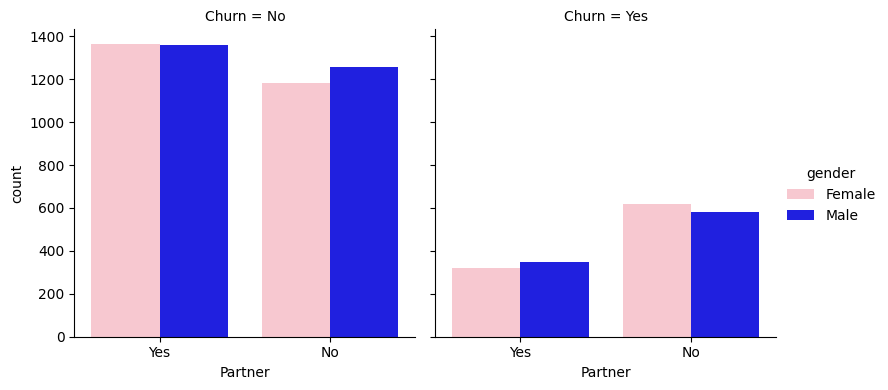

In [ ]:
sns.catplot(x="Partner", hue="gender", col="Churn",
            data=ndf, kind="count",
            palette={"Female":"pink","Male":"blue"},
            height=4, aspect=1)


**•	Customer Churn Rate – % of customers leaving in a given period.**

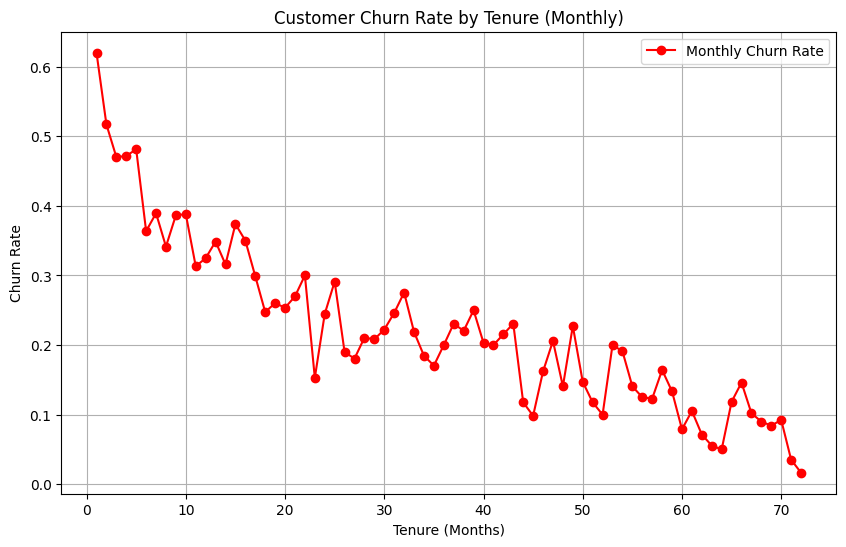

In [ ]:
# Step 1: Count churn vs non-churn by tenure month
monthly_counts = ndf.groupby(['tenure','Churn']).size().unstack(fill_value=0)

# Step 2: Calculate churn rate per month
monthly_counts['churn_rate'] = monthly_counts['Yes'] / (monthly_counts['Yes'] + monthly_counts['No'])

# Step 3: Plot churn rate by tenure month
plt.figure(figsize=(10,6))
plt.plot(monthly_counts.index, monthly_counts['churn_rate'], marker='o', color='red', label='Monthly Churn Rate')
plt.title("Customer Churn Rate by Tenure (Monthly)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
monthly_counts.head()

Churn,No,Yes,churn_rate
tenure,,,
1,233,380,0.619902
2,115,123,0.516807
3,106,94,0.470000
4,93,83,0.471591
5,69,64,0.481203


**Retention Rate – % of customers retained over time.**

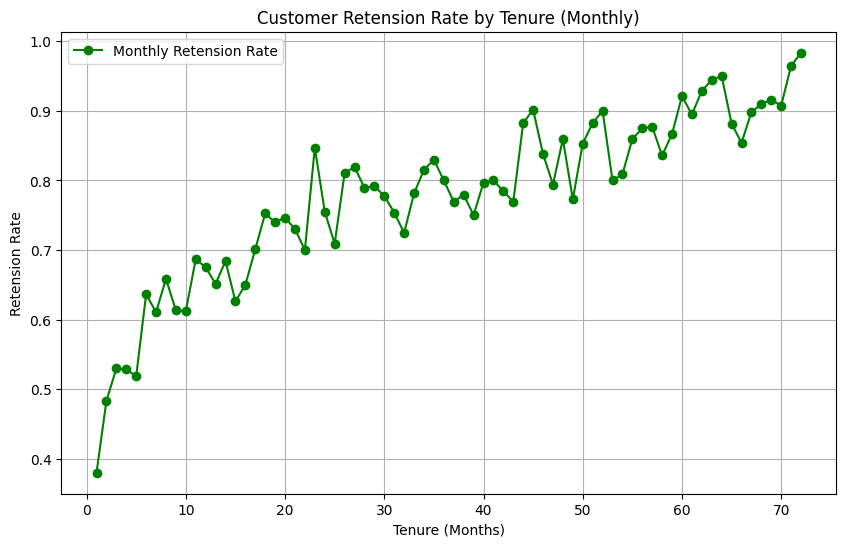

In [ ]:
# Step 1: Calculate retension rate per month
monthly_counts['retension_rate'] = monthly_counts['No'] / (monthly_counts['Yes'] + monthly_counts['No'])

# Step 2: Plot retension rate by tenure month
plt.figure(figsize=(10,6))
plt.plot(monthly_counts.index, monthly_counts['retension_rate'], marker='o', color='green', label='Monthly Retension Rate')
plt.title("Customer Retension Rate by Tenure (Monthly)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Retension Rate")
plt.legend()
plt.grid(True)
plt.show()

**What is exactly happening in early 0-12 months and remaining months to analyse the sharp churn rate in initial month**

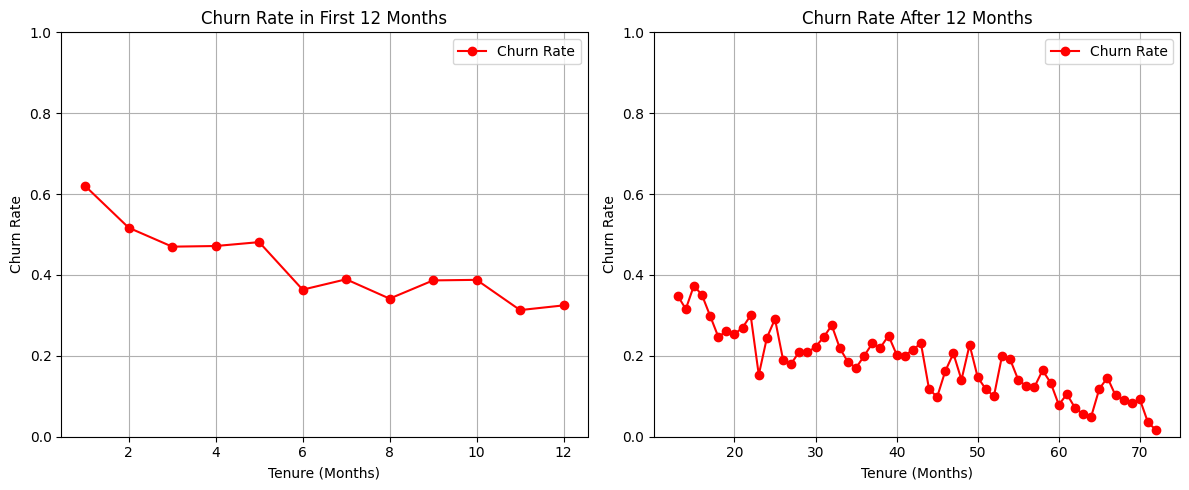

In [ ]:
import matplotlib.pyplot as plt

# Split into early (<=12 months) and later (>12 months)
early = monthly_counts[monthly_counts.index <= 12]
later = monthly_counts[monthly_counts.index > 12]

plt.figure(figsize=(12,5))

# Plot early tenure churn rate
plt.subplot(1,2,1)
plt.plot(early.index, early['churn_rate'], marker='o', color='red', label='Churn Rate')
plt.title("Churn Rate in First 12 Months")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0,1)
plt.legend()
plt.grid(True)

# Plot later tenure churn rate
plt.subplot(1,2,2)
plt.plot(later.index, later['churn_rate'], marker='o', color='red', label='Churn Rate')
plt.title("Churn Rate After 12 Months")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0,1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**the predominant contract type and billing method in the initial 6 months vs. 20–24 months of tenure**

In [ ]:
import pandas as pd

# Initial 6 months
early_period = ndf[(ndf['tenure'] <= 6)]
early_contract = early_period['Contract'].value_counts().idxmax()
early_billing = early_period['PaymentMethod'].value_counts().idxmax()

print("Initial 6 months:")
print("Predominant Contract:", early_contract)
print("Predominant Billing Method:", early_billing)

# 20–24 months
later_period = ndf[(ndf['tenure'] >= 20) & (ndf['tenure'] <= 24)]
later_contract = later_period['Contract'].value_counts().idxmax()
later_billing = later_period['PaymentMethod'].value_counts().idxmax()

print("\n20–24 months:")
print("Predominant Contract:", later_contract)
print("Predominant Billing Method:", later_billing)

Initial 6 months:
Predominant Contract: Month-to-month
Predominant Billing Method: Electronic check

20–24 months:
Predominant Contract: Month-to-month
Predominant Billing Method: Electronic check


/tmp/ipython-input-3894275466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Contract", data=early_period,
/tmp/ipython-input-3894275466.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Contract", data=later_period,


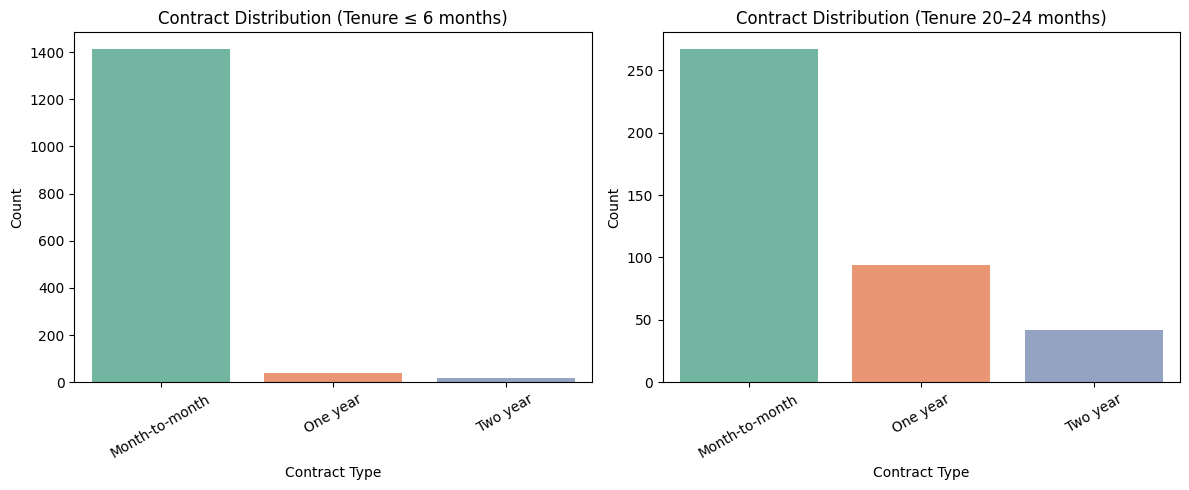

/tmp/ipython-input-3894275466.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PaymentMethod", data=early_period,
/tmp/ipython-input-3894275466.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PaymentMethod", data=later_period,


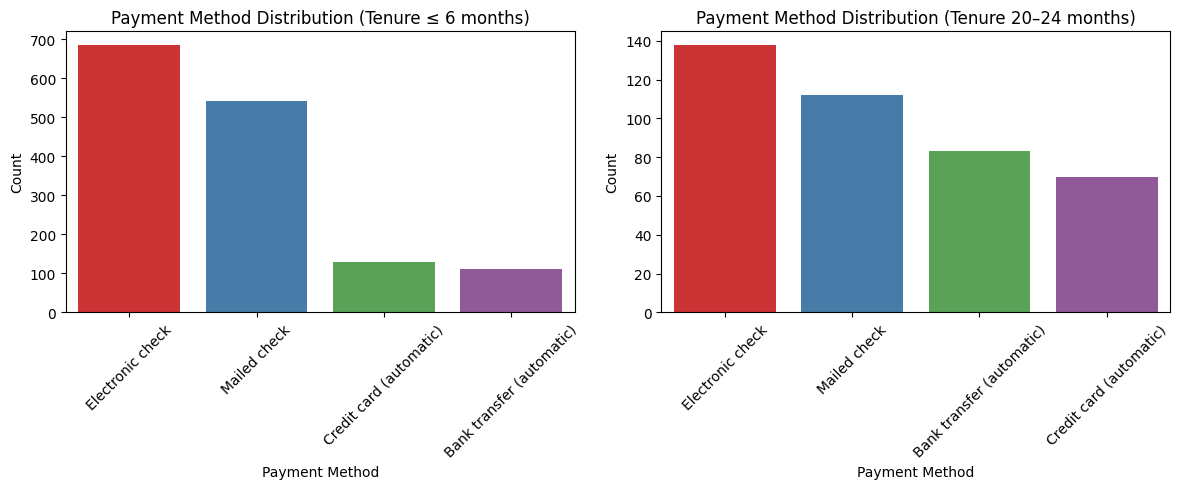

In [ ]:
# Plot side-by-side bar charts for Contract
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="Contract", data=early_period,
              order=early_period['Contract'].value_counts().index,
              palette="Set2")
plt.title("Contract Distribution (Tenure ≤ 6 months)")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.subplot(1,2,2)
sns.countplot(x="Contract", data=later_period,
              order=later_period['Contract'].value_counts().index,
              palette="Set2")
plt.title("Contract Distribution (Tenure 20–24 months)")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# Plot side-by-side bar charts for Payment Method
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="PaymentMethod", data=early_period,
              order=early_period['PaymentMethod'].value_counts().index,
              palette="Set1")
plt.title("Payment Method Distribution (Tenure ≤ 6 months)")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(x="PaymentMethod", data=later_period,
              order=later_period['PaymentMethod'].value_counts().index,
              palette="Set1")
plt.title("Payment Method Distribution (Tenure 20–24 months)")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**what is Early Tenure Churn rate and retention rate – % of customers leaving within the first 3–6 months**

In [ ]:
# Filter customers with tenure between 3 and 6 months
early_tenure = ndf[(ndf['tenure'] >= 3) & (ndf['tenure'] <= 6)]

# Count churners and total customers
churned = early_tenure[early_tenure['Churn'] == 'Yes'].shape[0]
retained = early_tenure[early_tenure['Churn'] == 'No'].shape[0]
total = early_tenure.shape[0]

# Calculate churn and retention rates
early_tenure_churn_rate = churned / total * 100
early_tenure_retention_rate = retained / total * 100

print(f"Early Tenure Churn Rate (3–6 months): {early_tenure_churn_rate:.2f}%")
print(f"Early Tenure Retention Rate (3–6 months): {early_tenure_retention_rate:.2f}%")

Early Tenure Churn Rate (3–6 months): 45.40%
Early Tenure Retention Rate (3–6 months): 54.60%


**Revenue & Value Metrics**

**•	Average Revenue Per User (ARPU) – Monthly revenue per customer**

Overall ARPU: 64.80


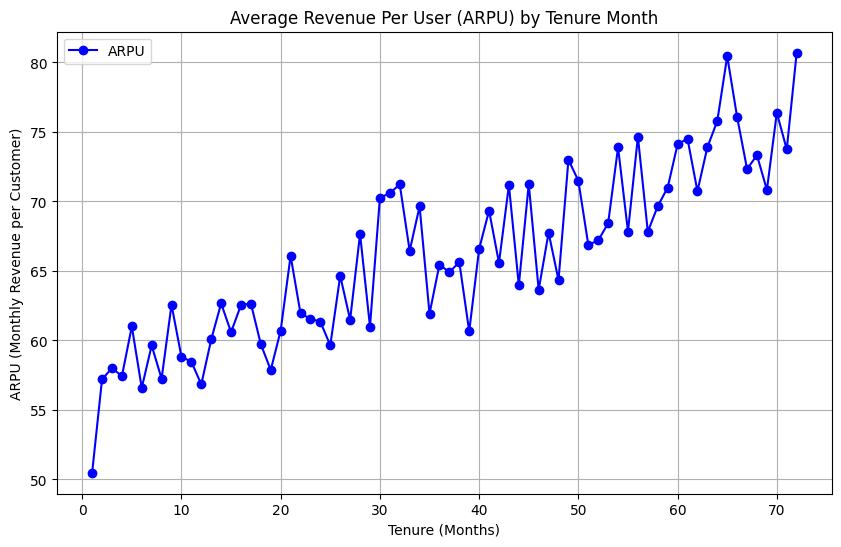

In [ ]:
# Step 1: Calculate ARPU (average monthly revenue per customer)
arpu = ndf['MonthlyCharges'].mean()
print(f"Overall ARPU: {arpu:.2f}")

# Step 2: Calculate ARPU by tenure month
arpu_by_tenure = ndf.groupby('tenure')['MonthlyCharges'].mean()

# Step 3: Plot ARPU trend
plt.figure(figsize=(10,6))
plt.plot(arpu_by_tenure.index, arpu_by_tenure.values, marker='o', color='blue', label='ARPU')
plt.title("Average Revenue Per User (ARPU) by Tenure Month")
plt.xlabel("Tenure (Months)")
plt.ylabel("ARPU (Monthly Revenue per Customer)")
plt.legend()
plt.grid(True)
plt.show()


- The upward trend means customers who stay longer tend to generate more revenue.
- ARPU is a critical KPI because it links customer retention directly to financial performance keeping customers longer not only reduces churn but also increases revenue per user.




**split ARPU by churn status so you can see whether churners tend to be low‑ARPU (price sensitive) or high‑ARPU (profitable but leaving).**



ARPU by Churn Status:
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


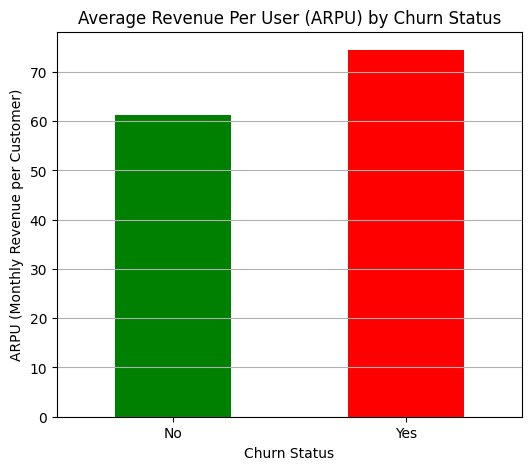

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Calculate ARPU by churn status
arpu_by_churn = ndf.groupby('Churn')['MonthlyCharges'].mean()

print("ARPU by Churn Status:")
print(arpu_by_churn)

# Step 2: Plot ARPU comparison
plt.figure(figsize=(6,5))
arpu_by_churn.plot(kind='bar', color=['green','red'])
plt.title("Average Revenue Per User (ARPU) by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("ARPU (Monthly Revenue per Customer)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

data shows : profitable customers are leaving, which signals deeper issues
- Bundled services dissatisfaction: Customers paying more for multiple services (internet + TV + phone) may churn if one service underperforms.
- Price sensitivity at higher tiers: Customers with premium plans may feel they’re not getting enough value compared to competitors.
- Contract flexibility: High‑ARPU customers often start on month‑to‑month contracts, making it easier to leave despite paying more.



**what is customer lifetime value**

In [ ]:
# Step 1: Calculate ARPU (average monthly revenue per customer)
arpu = ndf['MonthlyCharges'].mean()

# Step 2: Calculate Average Customer Lifetime (ACL)
# For churned customers, tenure is their lifetime
acl = ndf[ndf['Churn'] == 'Yes']['tenure'].mean()

# Step 3: Calculate CLV
clv = arpu * acl

print(f"Average Revenue Per User (ARPU): {arpu:.2f}")
print(f"Average Customer Lifetime (ACL): {acl:.2f} months")
print(f"Customer Lifetime Value (CLV): {clv:.2f}")


Average Revenue Per User (ARPU): 64.80
Average Customer Lifetime (ACL): 17.98 months
Customer Lifetime Value (CLV): 1165.02


**new column classifying customer into segments of HIGH ARPU and Customer Lifetime Value (CLV) till date**

In [ ]:

# Step 1: Define ARPU threshold for "High ARPU"
# For example, customers above the overall ARPU are considered "High ARPU"
arpu_threshold = ndf['MonthlyCharges'].mean()

# Step 2: Create a new column for ARPU segment
ndf['ARPU_segment'] = np.where(ndf['MonthlyCharges'] >= arpu_threshold, 'High ARPU', 'Low/Medium ARPU')

# Step 3: Calculate Customer Lifetime Value till date
# CLV till date = MonthlyCharges × tenure
ndf['CLV_till_date'] = ndf['MonthlyCharges'] * ndf['tenure']

# Step 4: Quick check
print(ndf[['MonthlyCharges','tenure','ARPU_segment','CLV_till_date']].head())

   MonthlyCharges  tenure     ARPU_segment  CLV_till_date
0           29.85       1  Low/Medium ARPU          29.85
1           56.95      34  Low/Medium ARPU        1936.30
2           53.85       2  Low/Medium ARPU         107.70
3           42.30      45  Low/Medium ARPU        1903.50
4           70.70       2        High ARPU         141.40


/tmp/ipython-input-1546212168.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['ARPU_segment'] = np.where(ndf['MonthlyCharges'] >= arpu_threshold, 'High ARPU', 'Low/Medium ARPU')
/tmp/ipython-input-1546212168.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['CLV_till_date'] = ndf['MonthlyCharges'] * ndf['tenure']


**visualize Customer Lifetime Value (CLV till date) split by ARPU segment (High vs. Low/Medium)**

/tmp/ipython-input-1682774998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ARPU_segment", y="CLV_till_date", data=ndf, palette="Set2")


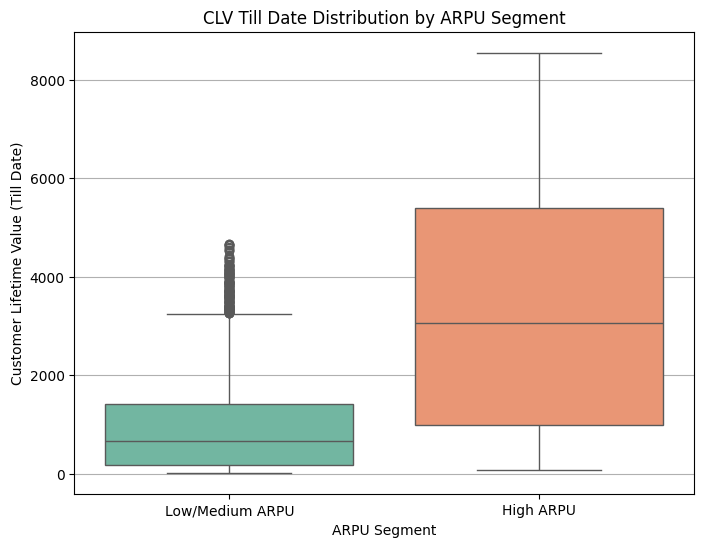

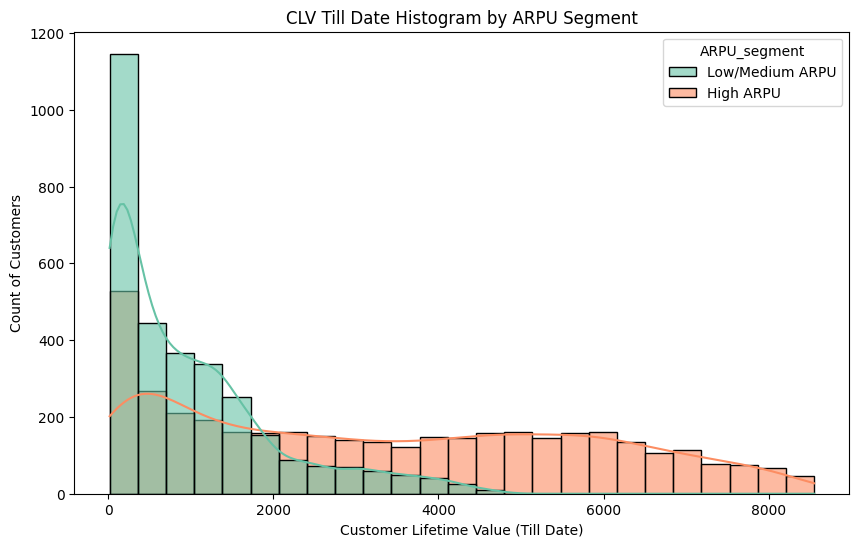

In [ ]:

# Boxplot of CLV till date by ARPU segment
plt.figure(figsize=(8,6))
sns.boxplot(x="ARPU_segment", y="CLV_till_date", data=ndf, palette="Set2")
plt.title("CLV Till Date Distribution by ARPU Segment")
plt.xlabel("ARPU Segment")
plt.ylabel("Customer Lifetime Value (Till Date)")
plt.grid(True, axis='y')
plt.show()

# Histogram for deeper comparison
plt.figure(figsize=(10,6))
sns.histplot(data=ndf, x="CLV_till_date", hue="ARPU_segment", kde=True, palette="Set2", alpha=0.6)
plt.title("CLV Till Date Histogram by ARPU Segment")
plt.xlabel("Customer Lifetime Value (Till Date)")
plt.ylabel("Count of Customers")
plt.show()

**The graph highlights that high‑ARPU customers are the most valuable but also the most volatile.**

**Traits of High ARPU churners**

/tmp/ipython-input-1793156937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-1793156937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-1793156937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-1793156937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False

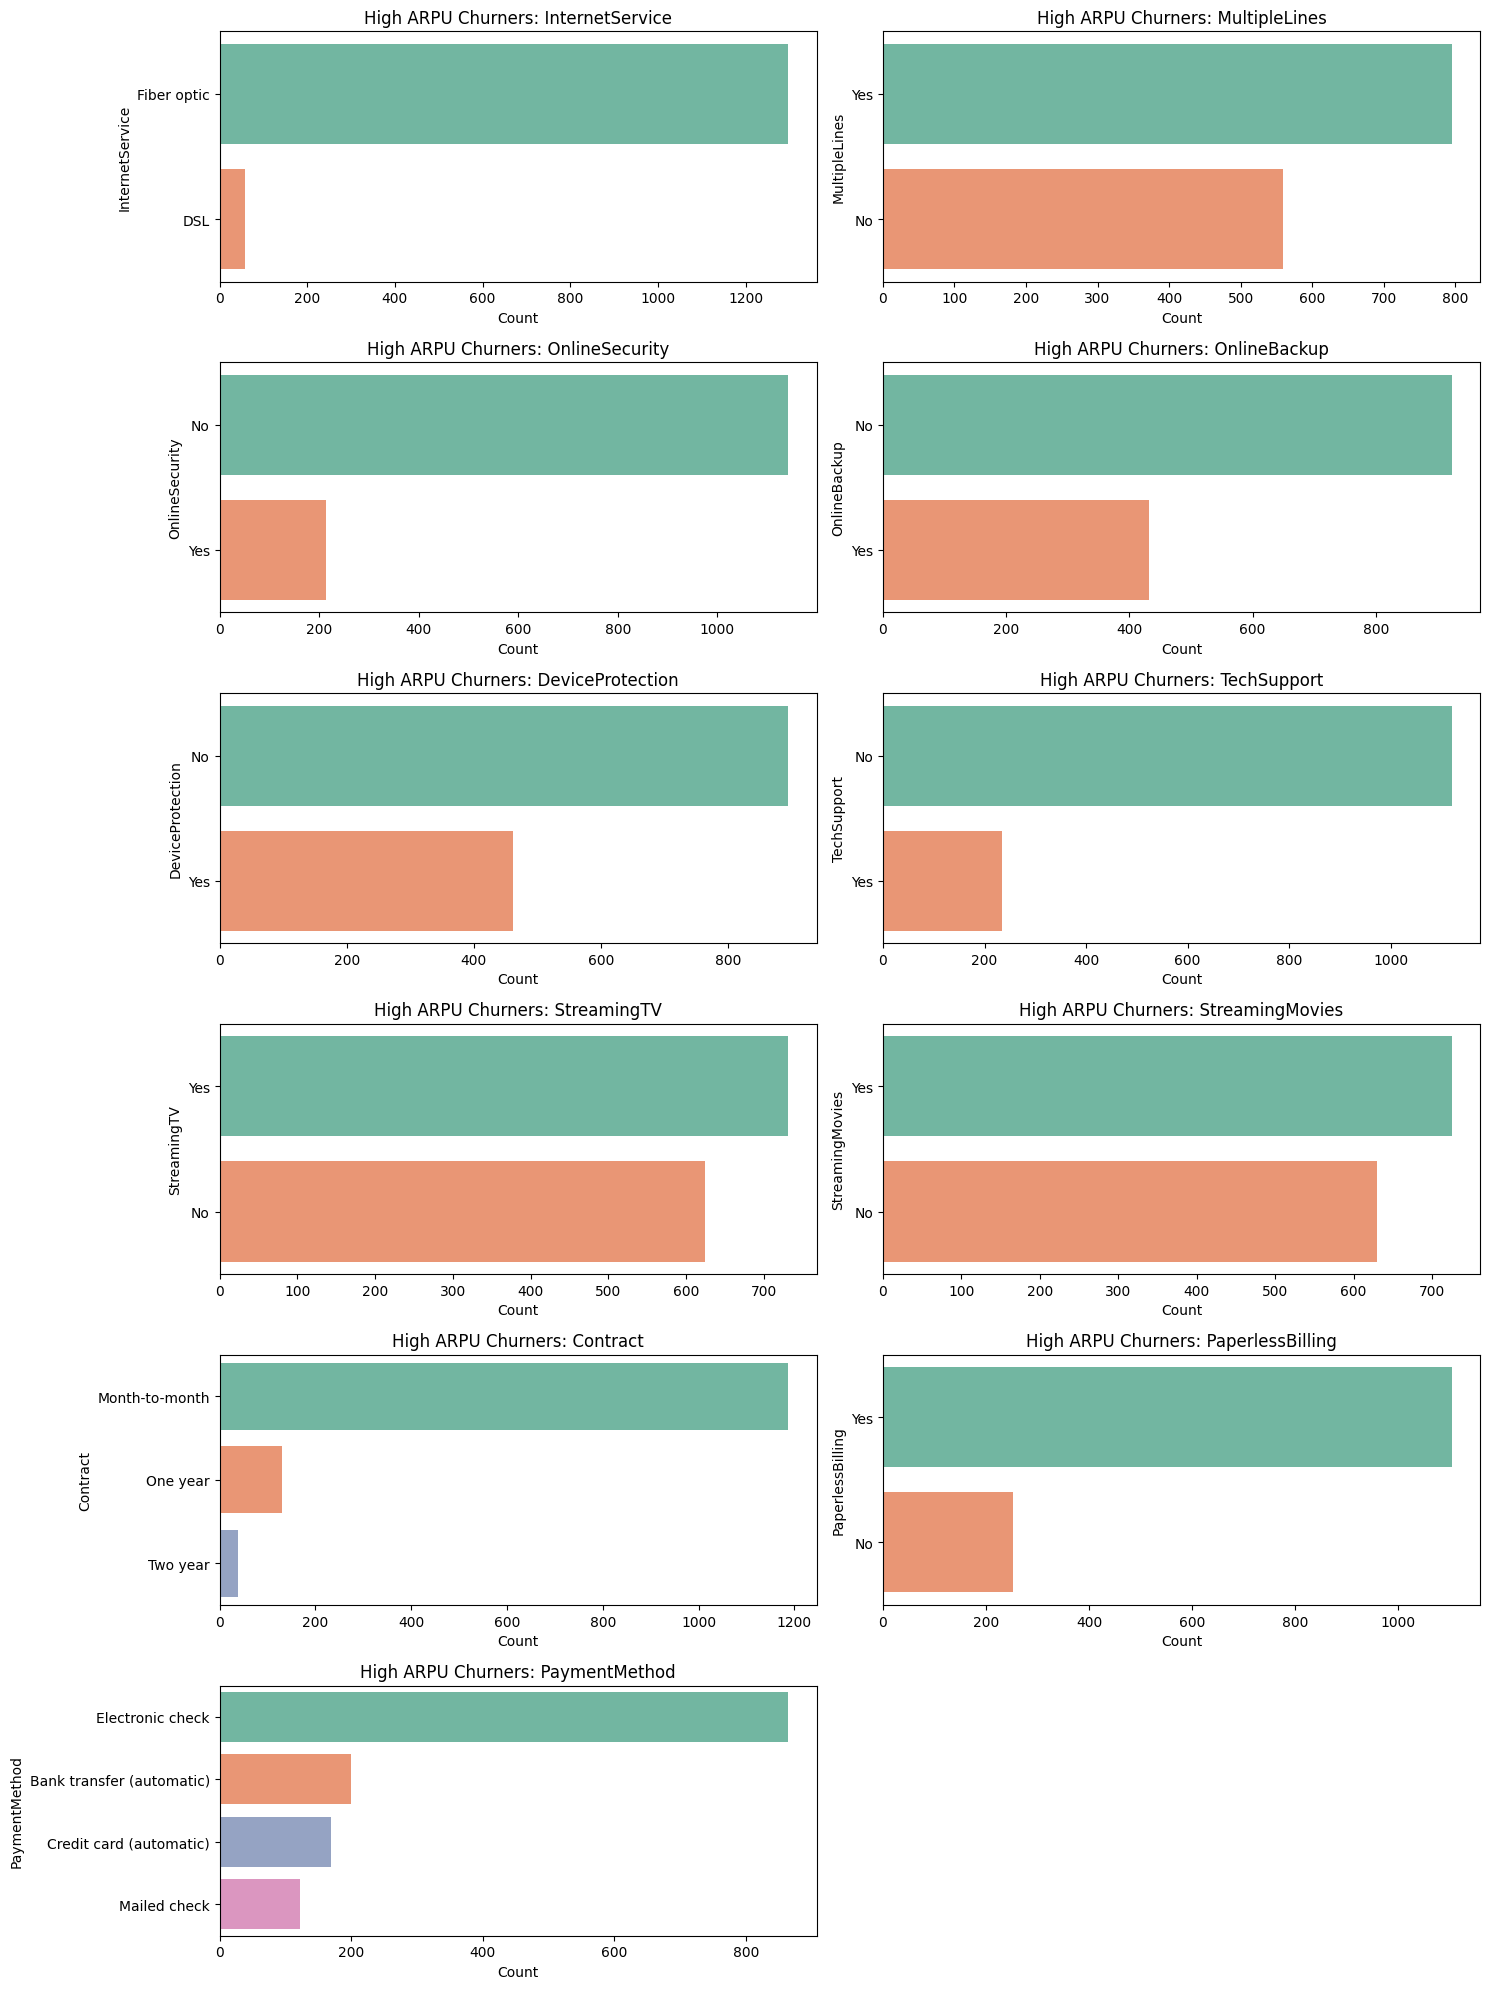

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter high ARPU churners
arpu_threshold = ndf['MonthlyCharges'].mean()
high_arpu_churners = ndf[(ndf['MonthlyCharges'] >= arpu_threshold) & (ndf['Churn'] == 'Yes')]

# Step 2: Select relevant service columns
service_cols = [
    'InternetService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Step 3: Plot count distributions for each service trait
plt.figure(figsize=(15,20))

for i, col in enumerate(service_cols, 1):
    plt.subplot(6,2,i)
    sns.countplot(y=col, data=high_arpu_churners,
                  order=high_arpu_churners[col].value_counts().index,
                  palette="Set2")
    plt.title(f"High ARPU Churners: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**traits of High ARPU Non Churners**

/tmp/ipython-input-3487031806.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-3487031806.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-3487031806.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=high_arpu_churners,
/tmp/ipython-input-3487031806.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False

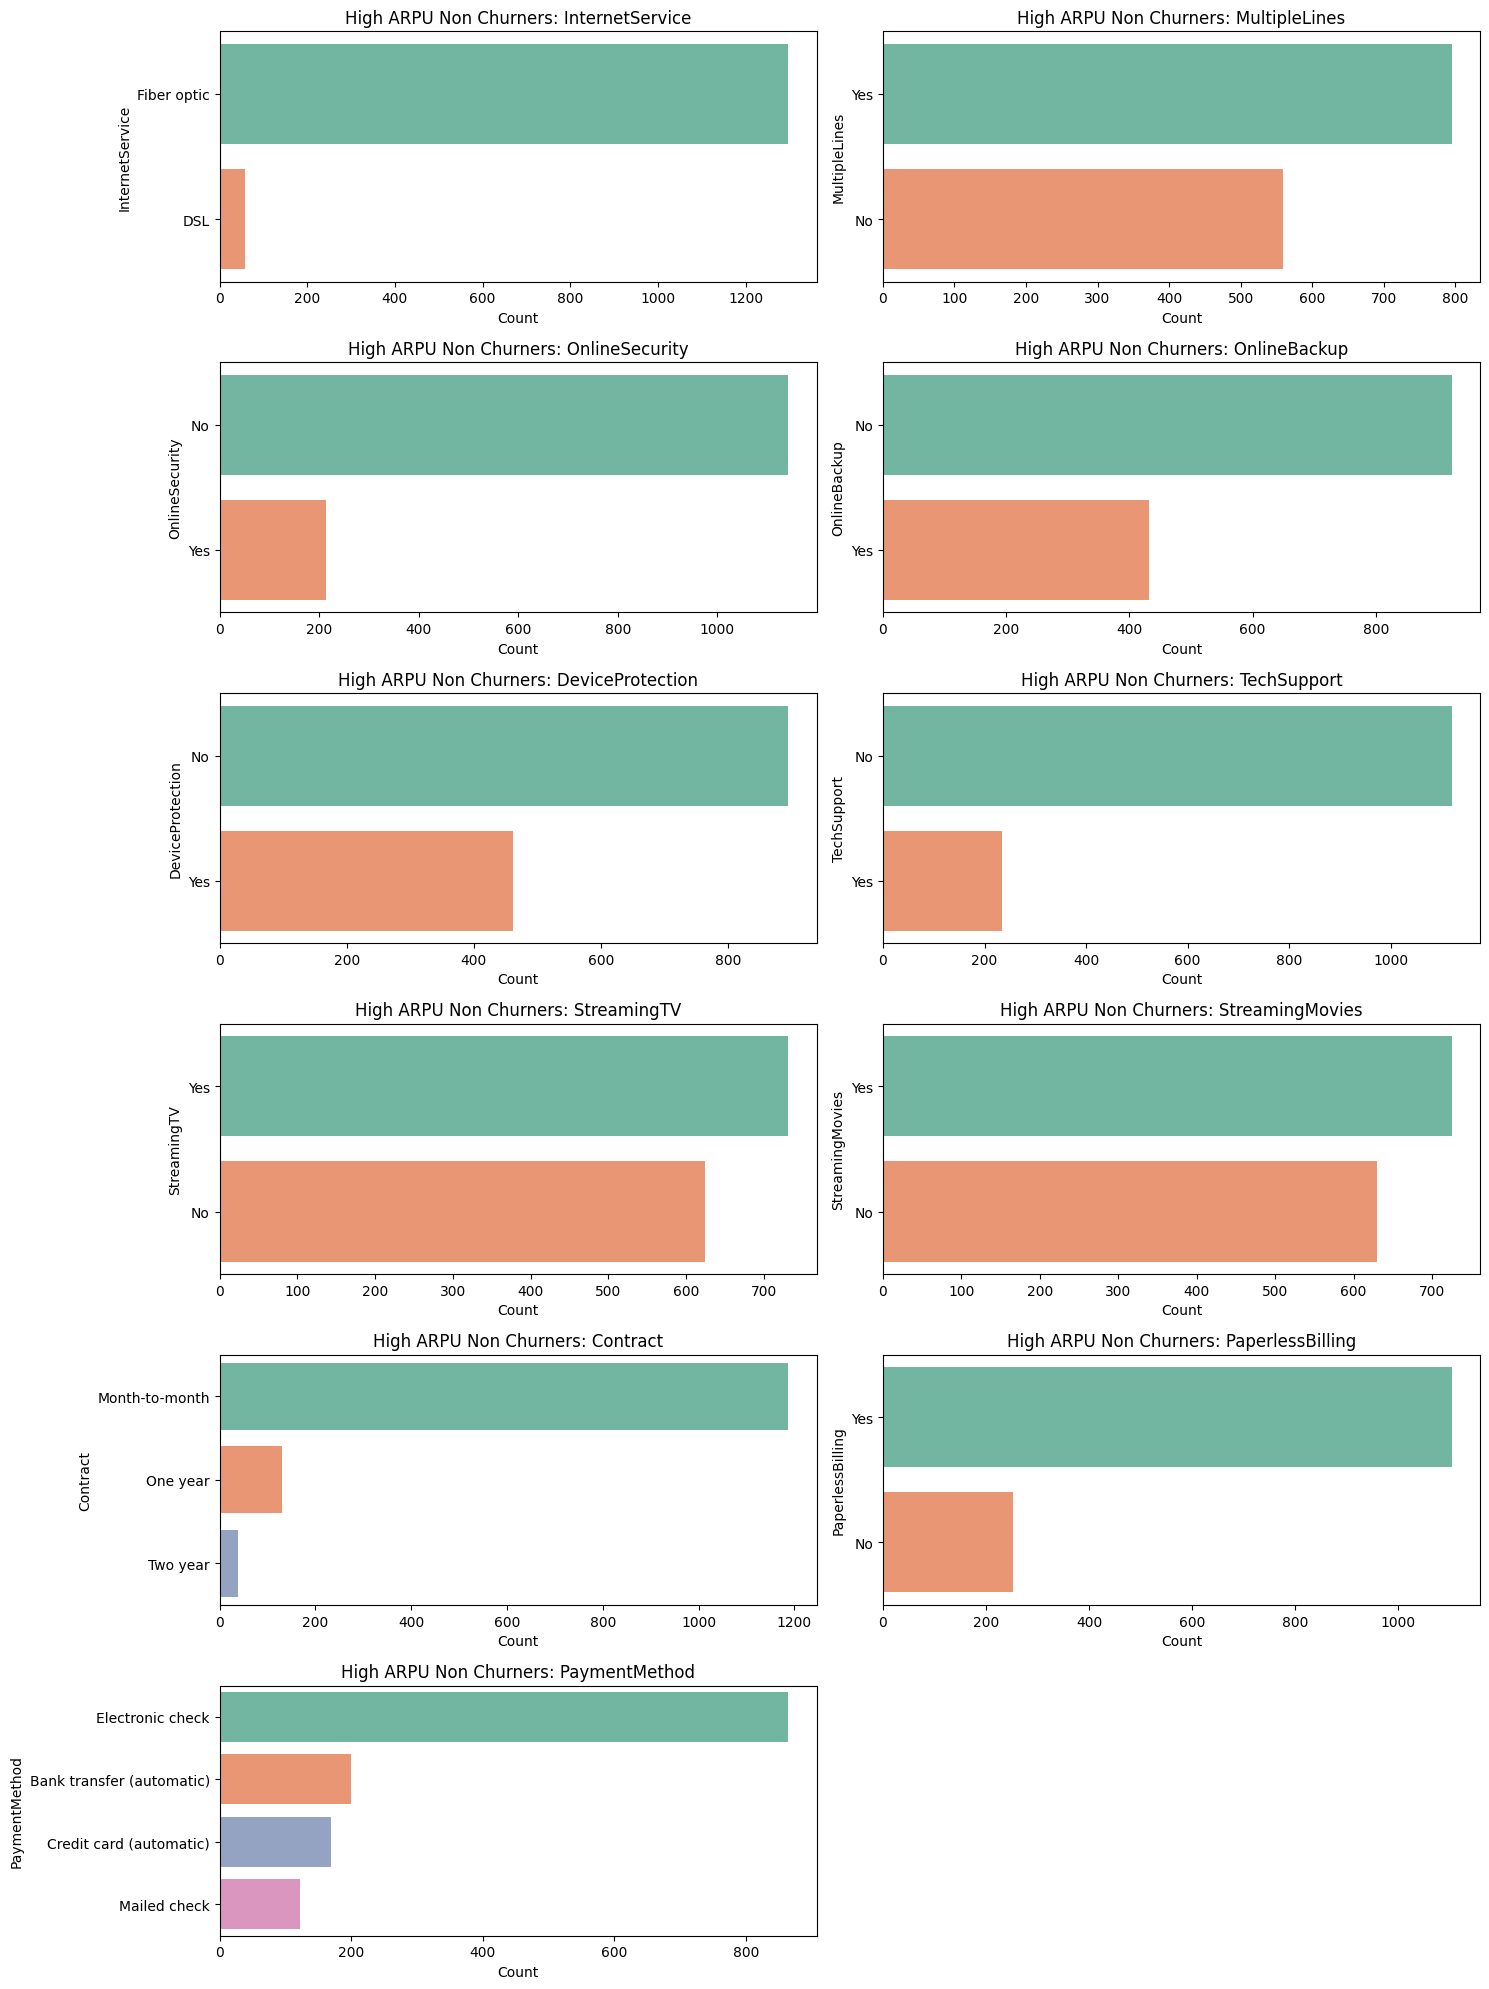

In [ ]:
# Step 1: Filter high ARPU churners
arpu_threshold = ndf['MonthlyCharges'].mean()
high_arpu_non_churners = ndf[(ndf['MonthlyCharges'] >= arpu_threshold) & (ndf['Churn'] == 'No')]

# Step 2: Select relevant service columns
service_cols = [
    'InternetService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Step 3: Plot count distributions for each service trait
plt.figure(figsize=(15,20))

for i, col in enumerate(service_cols, 1):
    plt.subplot(6,2,i)
    sns.countplot(y=col, data=high_arpu_churners,
                  order=high_arpu_churners[col].value_counts().index,
                  palette="Set2")
    plt.title(f"High ARPU Non Churners: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Revenue Loss from Churn — the total revenue lost due to churned customers**

In [ ]:
# Step 1: Calculate CLV till date for all customers
ndf['CLV_till_date'] = ndf['MonthlyCharges'] * ndf['tenure']

# Step 2: Filter churned customers
churned_customers = ndf[ndf['Churn'] == 'Yes']

# Step 3: Calculate total revenue loss from churn
revenue_loss_from_churn = churned_customers['CLV_till_date'].sum()

print(f"Revenue Loss from Churn: {revenue_loss_from_churn:.2f}")

Revenue Loss from Churn: 2862576.90


/tmp/ipython-input-2149883036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['CLV_till_date'] = ndf['MonthlyCharges'] * ndf['tenure']


**•	Upsell/Cross sell Rate – Measures success in increasing customer value before churn.**

In [ ]:
# Step 1: Define add-on service columns
addon_services = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Step 2: Filter churned customers
churned = ndf.loc[ndf['Churn'] == 'Yes'].copy()

# Step 3: Count add-on services per churned customer
churned['addon_count'] = churned[addon_services].apply(lambda row: (row == 'Yes').sum(), axis=1)

# Step 4: Calculate Upsell/Cross-sell Rate
churned_with_addons = (churned['addon_count'] > 0).sum()
total_churned = churned.shape[0]
upsell_rate = churned_with_addons / total_churned * 100

print(f"Upsell/Cross-sell Rate among churned customers: {upsell_rate:.2f}%")

Upsell/Cross-sell Rate among churned customers: 81.49%


**Net Promoter Score (NPS) is a widely used measure of customer loyalty and their likelihood to recommend your service to others**

approximate loyalty using existing features:
- Churn = Yes → proxy for detractors
- Long tenure + multiple services → proxy for promoters
- Medium tenure → proxy for passives


In [ ]:
def classify_nps(row):
    if row['Churn'] == 'Yes':
        return 'Detractor'
    elif row['tenure'] >= 24 and (row['StreamingTV'] == 'Yes' or row['StreamingMovies'] == 'Yes'):
        return 'Promoter'
    else:
        return 'Passive'

ndf['NPS_Category'] = ndf.apply(classify_nps, axis=1)

# Calculate percentages
promoters = (ndf['NPS_Category'] == 'Promoter').mean() * 100
detractors = (ndf['NPS_Category'] == 'Detractor').mean() * 100
nps = promoters - detractors

print(f"Promoters: {promoters:.2f}%")
print(f"Detractors: {detractors:.2f}%")
print(f"Proxy NPS: {nps:.2f}")

Promoters: 27.30%
Detractors: 26.58%
Proxy NPS: 0.73


/tmp/ipython-input-1451461444.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['NPS_Category'] = ndf.apply(classify_nps, axis=1)


/tmp/ipython-input-1088771949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_counts.index, y=nps_counts.values, palette="Set2")


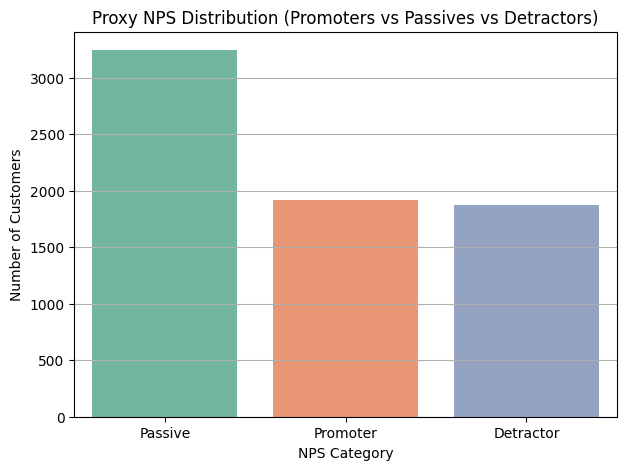

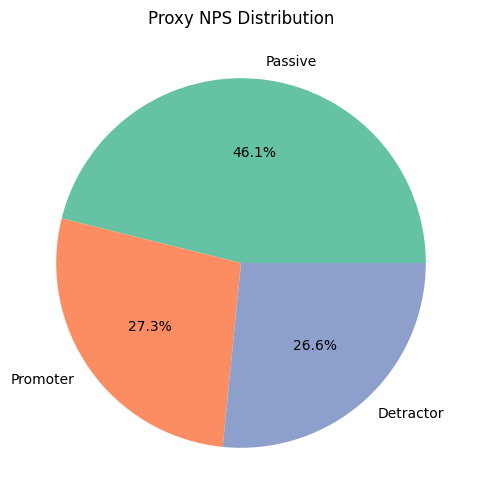

In [ ]:
# Count distribution of NPS categories
nps_counts = ndf['NPS_Category'].value_counts()

# Bar plot
plt.figure(figsize=(7,5))
sns.barplot(x=nps_counts.index, y=nps_counts.values, palette="Set2")
plt.title("Proxy NPS Distribution (Promoters vs Passives vs Detractors)")
plt.xlabel("NPS Category")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.show()

# Pie chart for proportions
plt.figure(figsize=(6,6))
plt.pie(nps_counts.values, labels=nps_counts.index, autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("Proxy NPS Distribution")
plt.show()


**Traits shown by Detractors**

/tmp/ipython-input-877426005.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=detractors,
/tmp/ipython-input-877426005.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=detractors,
/tmp/ipython-input-877426005.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=detractors,
/tmp/ipython-input-877426005.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sn

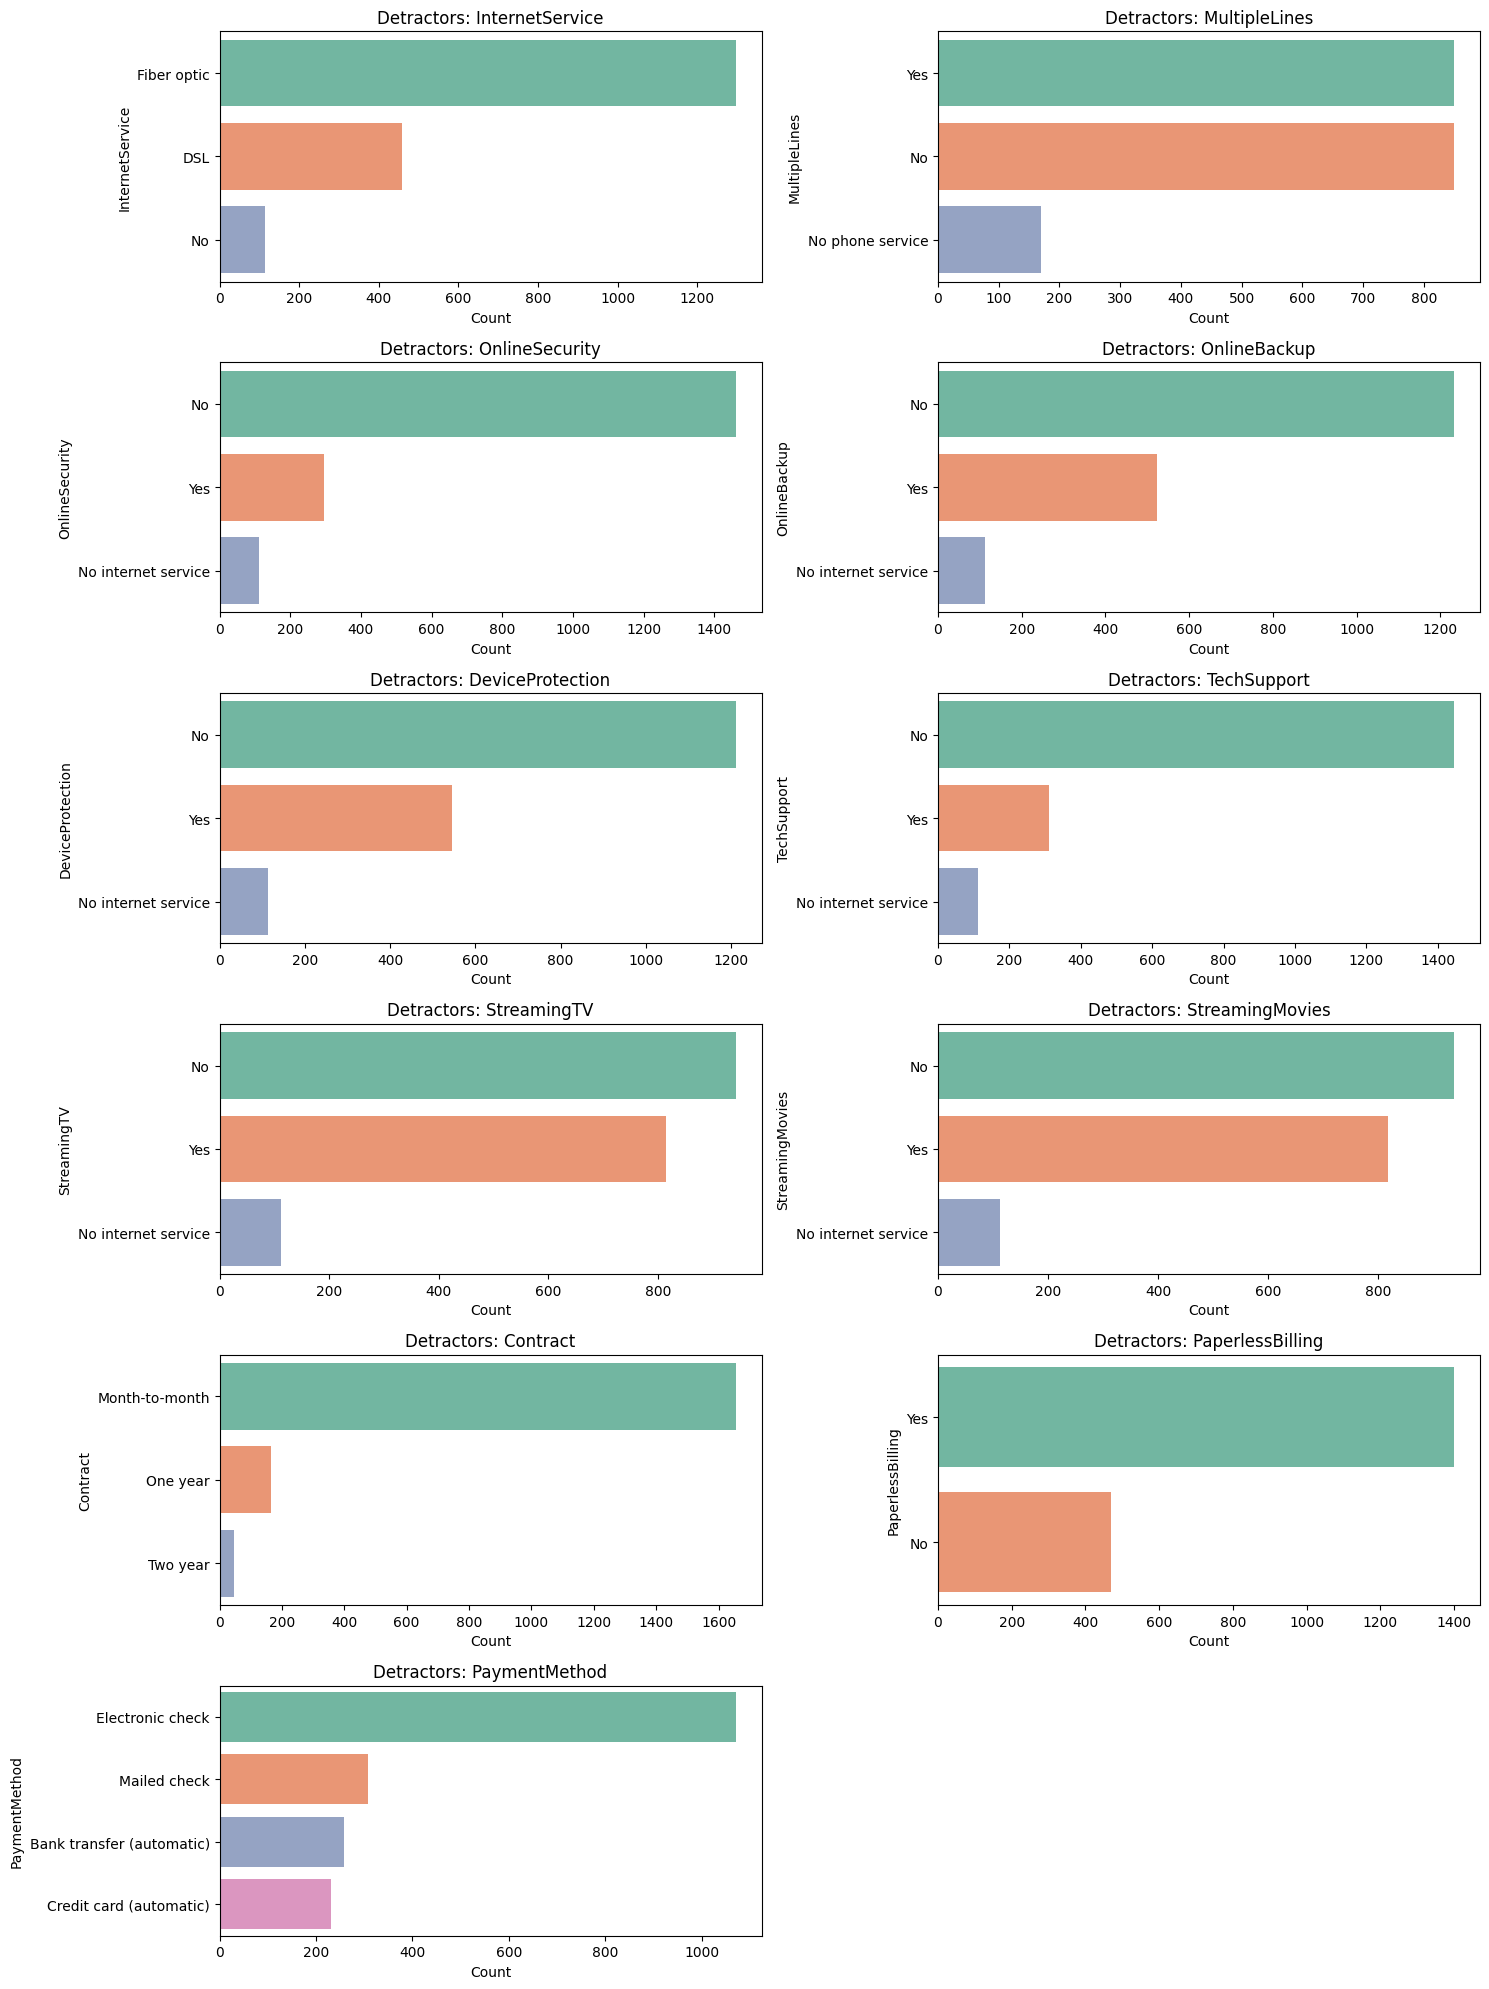

In [ ]:
# Step 1: Filter detractors
detractors = ndf.loc[ndf['NPS_Category'] == 'Detractor'].copy()

# Step 2: Define service-related columns to analyze
service_cols = [
    'InternetService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Step 3: Plot distributions for each trait
plt.figure(figsize=(15,20))

for i, col in enumerate(service_cols, 1):
    plt.subplot(6,2,i)
    sns.countplot(y=col, data=detractors,
                  order=detractors[col].value_counts().index,
                  palette="Set2")
    plt.title(f"Detractors: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


**checking unique value in each column to convert them later**

In [ ]:
def print_unique_col_values(df):
    for column in df:
      #print(ndf[column].unique())
      #if column names are also required
      if df[column].dtypes == 'object':
        print(f'{column} : {df[column].unique()}')

In [ ]:
print_unique_col_values(ndf)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']
gender_churn : ['Female-No' 'Male-No' 'Male-Yes' 'Female-Yes']
ARPU_segment : ['Low/Medium ARPU' 'High ARPU']
NPS_Category : ['Passive' 'Detractor' 'Promoter']


Since "No internet srvices", "No phone service" means no itself, therefore replace them with "No"

In [ ]:
ndf.replace('No internet service', 'No', inplace=True)
ndf.replace('No phone service', 'No', inplace=True)

/tmp/ipython-input-3604587050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf.replace('No internet service', 'No', inplace=True)
/tmp/ipython-input-3604587050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf.replace('No phone service', 'No', inplace=True)


In [ ]:
print_unique_col_values(ndf)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']
gender_churn : ['Female-No' 'Male-No' 'Male-Yes' 'Female-Yes']
ARPU_segment : ['Low/Medium ARPU' 'High ARPU']
NPS_Category : ['Passive' 'Detractor' 'Promoter']


In [ ]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies', 'PaperlessBilling', 'Churn' ]

for column in yes_no_columns:
  ndf[column].replace({'Yes':1, 'No': 0}, inplace=True)

/tmp/ipython-input-3932982530.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ndf[column].replace({'Yes':1, 'No': 0}, inplace=True)
/tmp/ipython-input-3932982530.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ndf[column].replace({'Yes':1, 'No': 0}, inplace=True)
/tmp/ipython-input-393298253

In [ ]:
ndf[column].unique()

array([0, 1])

In [ ]:
for col in ndf:
  print(f'{col} : {ndf[col].unique()}')

gender : [1 0]
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [0 1]
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService : [0 1]
MultipleLines : [0 1]
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : [0 1]
OnlineBackup : [1 0]
DeviceProtection : [0 1]
TechSupport : [0 1]
StreamingTV : [0 1]
StreamingMovies : [0 1]
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : [1 0]
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges : [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn : [0 1]
gender_churn : ['Female-No' 'Male-No' 'Male-Yes' 'Female-Yes']
ARPU_segment : ['Low/Medium ARPU' 'High ARPU']
CLV_till_date : [  29.85 1936.3   107.7  .

In [ ]:
ndf['gender'].replace({'Female': 1, 'Male': 0}, inplace=True)


/tmp/ipython-input-3855174820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ndf['gender'].replace({'Female': 1, 'Male': 0}, inplace=True)


In [ ]:
for col in ndf:
  print(f'{col} : {ndf[col].unique()}')

gender : [1 0]
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [0 1]
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService : [0 1]
MultipleLines : [0 1]
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : [0 1]
OnlineBackup : [1 0]
DeviceProtection : [0 1]
TechSupport : [0 1]
StreamingTV : [0 1]
StreamingMovies : [0 1]
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : [1 0]
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges : [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn : [0 1]
gender_churn : ['Female-No' 'Male-No' 'Male-Yes' 'Female-Yes']
ARPU_segment : ['Low/Medium ARPU' 'High ARPU']
CLV_till_date : [  29.85 1936.3   107.7  .

Now to replace the columns having more than three categories values then instead of replace function, "one hot encoding is used"

In [ ]:
#pd.get_dummies(data = ndf, columns=['InternetService'])
#instead of true and false replace them with one and zero
ndf1 = pd.get_dummies(data = ndf, columns=['InternetService', 'Contract', 'PaymentMethod', 'gender_churn', 'ARPU_segment', 'NPS_Category' ], drop_first=True, dtype=int)

In [ ]:
ndf1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_churn_Female-Yes,gender_churn_Male-No,gender_churn_Male-Yes,ARPU_segment_Low/Medium ARPU,NPS_Category_Passive,NPS_Category_Promoter
0,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,1,0
1,0,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,1,0,1,1,0
2,0,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,1,1,0,0
3,0,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,1,0,1,1,0
4,1,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0


To scale the column values of monthly charges, Total charges and tenure, since other columns have '0' and '1' values

In [ ]:
#ndf1.standard = (ndf.MonthlyCharges - ndf.MonthlyCharges.min()) / (ndf.MonthlyCharges.max() - ndf.MonthlyCharges.min())
#ndf1.standard

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
ndf1[['MonthlyCharges', 'TotalCharges', 'tenure', 'CLV_till_date']] = scaler.fit_transform(ndf[['MonthlyCharges', 'TotalCharges', 'tenure','CLV_till_date']])
ndf1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_churn_Female-Yes,gender_churn_Male-No,gender_churn_Male-Yes,ARPU_segment_Low/Medium ARPU,NPS_Category_Passive,NPS_Category_Promoter
0,1,0,1,0,0.000000,0,0,0,1,0,...,0,0,1,0,0,0,0,1,1,0
1,0,0,0,0,0.464789,1,0,1,0,1,...,0,0,0,1,0,1,0,1,1,0
2,0,0,0,0,0.014085,1,0,1,1,0,...,0,0,0,1,0,0,1,1,0,0
3,0,0,0,0,0.619718,0,0,1,0,1,...,0,0,0,0,0,1,0,1,1,0
4,1,0,0,0,0.014085,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0


In [ ]:
x = ndf1.drop('CLV_till_date', axis=1)
y = ndf1['CLV_till_date']

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = ndf1.drop('CLV_till_date', axis=1)
y = ndf1['CLV_till_date']

# First split: train + temp (validation+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=100
)

# Second split: validation + test from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=100
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (4922, 30)
Validation size: (1055, 30)
Test size: (1055, 30)


In [ ]:
x_train.shape

(5625, 30)

In [ ]:
len(x_train.columns)

30

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=100),
    "XGBoost": XGBRegressor(random_state=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    results[name] = {"MSE": mse, "R2": r2}

# Display validation results
for model_name, metrics in results.items():
    print(f"{model_name}: MSE={metrics['MSE']:.2f}, R2={metrics['R2']:.2f}")

Linear Regression: MSE=0.00, R2=1.00
Ridge Regression: MSE=0.00, R2=1.00
Lasso Regression: MSE=0.00, R2=0.98
Random Forest: MSE=0.00, R2=1.00
Gradient Boosting: MSE=0.00, R2=1.00
XGBoost: MSE=0.00, R2=1.00


In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(20, input_shape=(30,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
     keras.layers.Dense(10, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: could not convert string to float: 'Male-No'

In [ ]:
model_prediction = model.predict(x_test)

In [ ]:
model_prediction[:5]

Since model prediction is in terms on array where each number represents the probablity and y_test is in form of 0 or 1

In [ ]:
y_pred = []
for element in model_prediction:
  if element > 0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

In [ ]:
y_pred[:10]

In [ ]:
y_test[:10]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predictions')
plt.ylabel('True Values')

In [ ]:
#Accuracy = (True Prediction/ Total Predictions)
round(((903+204)/(903+204+190+110)),2)

Precision for zero: No. of actual zero values predicted / total predicted value for zero

In [ ]:
round(((903)/(190+903)),2)

Precision for one: No. of actual zero values predicted / total predicted value for zero

In [ ]:
round(((204)/(204+110)),2)